1) Configuración inicial y conexión a Drive

In [ ]:
# CELDA 1: Configuración inicial, conexión a Drive e importación de librerías
!pip install -q scikit-learn pandas numpy matplotlib seaborn

# Conectar a Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Crear carpeta para el proyecto en Drive
import os
project_path = '/content/drive/MyDrive/Clustering_Circles_Project'
if not os.path.exists(project_path):
    os.makedirs(project_path)
    print(f"Carpeta creada: {project_path}")
else:
    print(f"Carpeta existente: {project_path}")

# Cambiar al directorio del proyecto
os.chdir(project_path)
print(f"Directorio de trabajo: {os.getcwd()}")

# Importar librerías
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_circles
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, SpectralClustering
from sklearn.metrics import adjusted_rand_score, v_measure_score
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.model_selection import ParameterGrid
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics.pairwise import rbf_kernel
import warnings
warnings.filterwarnings('ignore')

# Configurar estilo de gráficos
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

print("Librerías importadas correctamente")
print(f"Directorio de trabajo: {os.getcwd()}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Carpeta creada: /content/drive/MyDrive/Clustering_Circles_Project
Directorio de trabajo: /content/drive/MyDrive/Clustering_Circles_Project
Librerías importadas correctamente
Directorio de trabajo: /content/drive/MyDrive/Clustering_Circles_Project


2) Generación y exploración del dataset

GENERACION DEL DATASET CIRCLES

Informacion del dataset:
  Numero de muestras: 500
  Caracteristicas: 2
  Clases unicas: [0 1]
  Distribucion: [250 250]

Dataset guardado en: /content/drive/MyDrive/Clustering_Circles_Project


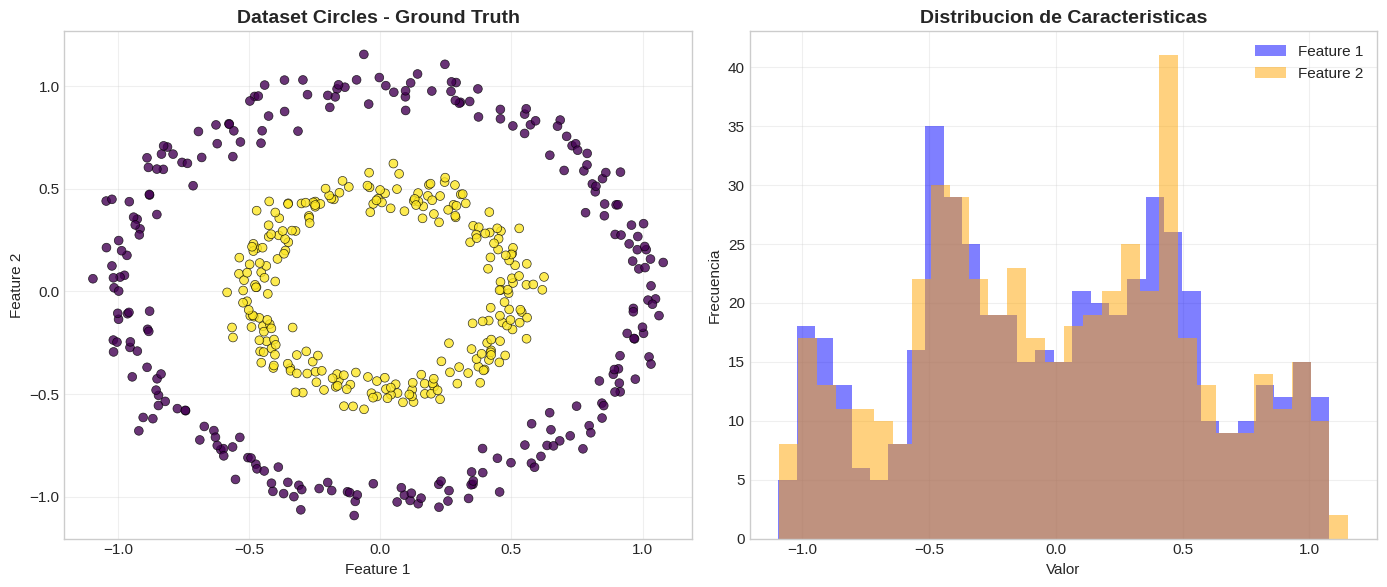

Gráfica guardada en: /content/drive/MyDrive/Clustering_Circles_Project/dataset_initial_exploration.png


In [ ]:
# CELDA 2: Generar y explorar dataset circles
print("="*70)
print("GENERACION DEL DATASET CIRCLES")
print("="*70)

# Generar dataset con parámetros ajustables
n_samples = 500
factor = 0.5
noise = 0.05

X_circles, y_true_circles = make_circles(
    n_samples=n_samples,
    factor=factor,
    noise=noise,
    random_state=42
)

print(f"\nInformacion del dataset:")
print(f"  Numero de muestras: {n_samples}")
print(f"  Caracteristicas: {X_circles.shape[1]}")
print(f"  Clases unicas: {np.unique(y_true_circles)}")
print(f"  Distribucion: {np.bincount(y_true_circles)}")

# Guardar dataset en Drive
np.save(f'{project_path}/X_circles.npy', X_circles)
np.save(f'{project_path}/y_true_circles.npy', y_true_circles)
print(f"\nDataset guardado en: {project_path}")

# Visualización inicial
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(X_circles[:, 0], X_circles[:, 1],
                c=y_true_circles, cmap='viridis',
                s=40, alpha=0.8, edgecolors='k', linewidth=0.5)
axes[0].set_title('Dataset Circles - Ground Truth', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Feature 1')
axes[0].set_ylabel('Feature 2')
axes[0].grid(True, alpha=0.3)

axes[1].hist(X_circles[:, 0], bins=30, alpha=0.5, label='Feature 1', color='blue')
axes[1].hist(X_circles[:, 1], bins=30, alpha=0.5, label='Feature 2', color='orange')
axes[1].set_title('Distribucion de Caracteristicas', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Valor')
axes[1].set_ylabel('Frecuencia')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{project_path}/dataset_initial_exploration.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"Gráfica guardada en: {project_path}/dataset_initial_exploration.png")

3) Exploración interactiva del dataset

In [ ]:
# CELDA 3: Exploración interactiva del dataset
from ipywidgets import interact, IntSlider, FloatSlider

def explorar_dataset(n_samples=500, factor=0.5, noise=0.05):
    """Exploracion interactiva del dataset"""
    X, y = make_circles(n_samples=n_samples, factor=factor, noise=noise, random_state=42)

    plt.figure(figsize=(10, 6))
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', s=30, alpha=0.7,
                edgecolors='k', linewidth=0.5)
    plt.title(f'Circulos: n={n_samples}, factor={factor:.2f}, noise={noise:.2f}',
              fontsize=14, fontweight='bold')
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.grid(True, alpha=0.3)
    plt.show()

    print(f"Estadisticas:")
    print(f"  Clases: {np.unique(y)}")
    print(f"  Distribucion: {np.bincount(y)}")
    print(f"  Forma: {X.shape}")

print("AJUSTA LOS PARAMETROS PARA EXPLORAR EL DATASET:")
interact(explorar_dataset,
         n_samples=IntSlider(min=100, max=1000, step=100, value=500, description='Muestras'),
         factor=FloatSlider(min=0.1, max=0.9, step=0.1, value=0.5, description='Factor'),
         noise=FloatSlider(min=0.0, max=0.2, step=0.01, value=0.05, description='Ruido'))

AJUSTA LOS PARAMETROS PARA EXPLORAR EL DATASET:


interactive(children=(IntSlider(value=500, description='Muestras', max=1000, min=100, step=100), FloatSlider(v…

<function __main__.explorar_dataset(n_samples=500, factor=0.5, noise=0.05)>

4) Escalado de datos


PREPROCESAMIENTO - ESCALADO DE DATOS
Datos escalados correctamente
  Media: [-0. -0.]
  Desviacion estandar: [1. 1.]
Scaler guardado en: /content/drive/MyDrive/Clustering_Circles_Project/scaler.pkl


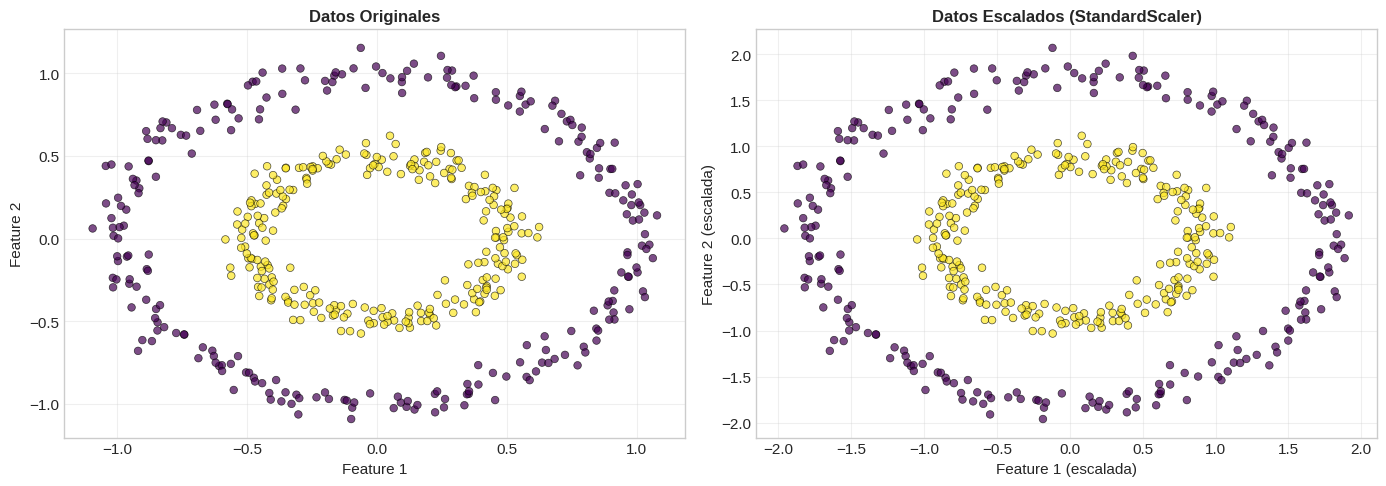

In [ ]:
# CELDA 4: Escalado de datos
print("\n" + "="*70)
print("PREPROCESAMIENTO - ESCALADO DE DATOS")
print("="*70)

scaler = StandardScaler()
X_circles_scaled = scaler.fit_transform(X_circles)

print("Datos escalados correctamente")
print(f"  Media: {X_circles_scaled.mean(axis=0).round(3)}")
print(f"  Desviacion estandar: {X_circles_scaled.std(axis=0).round(3)}")

# Guardar datos escalados
np.save(f'{project_path}/X_circles_scaled.npy', X_circles_scaled)

# Guardar el scaler
import joblib
joblib.dump(scaler, f'{project_path}/scaler.pkl')
print(f"Scaler guardado en: {project_path}/scaler.pkl")

# Visualizar comparación
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(X_circles[:, 0], X_circles[:, 1], c=y_true_circles,
                cmap='viridis', s=30, alpha=0.7, edgecolors='k', linewidth=0.5)
axes[0].set_title('Datos Originales', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Feature 1')
axes[0].set_ylabel('Feature 2')
axes[0].grid(True, alpha=0.3)

axes[1].scatter(X_circles_scaled[:, 0], X_circles_scaled[:, 1],
                c=y_true_circles, cmap='viridis', s=30, alpha=0.7, edgecolors='k', linewidth=0.5)
axes[1].set_title('Datos Escalados (StandardScaler)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Feature 1 (escalada)')
axes[1].set_ylabel('Feature 2 (escalada)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{project_path}/scaled_data_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

5) Método del Codo para K-means


METODO DEL CODO - K-MEANS


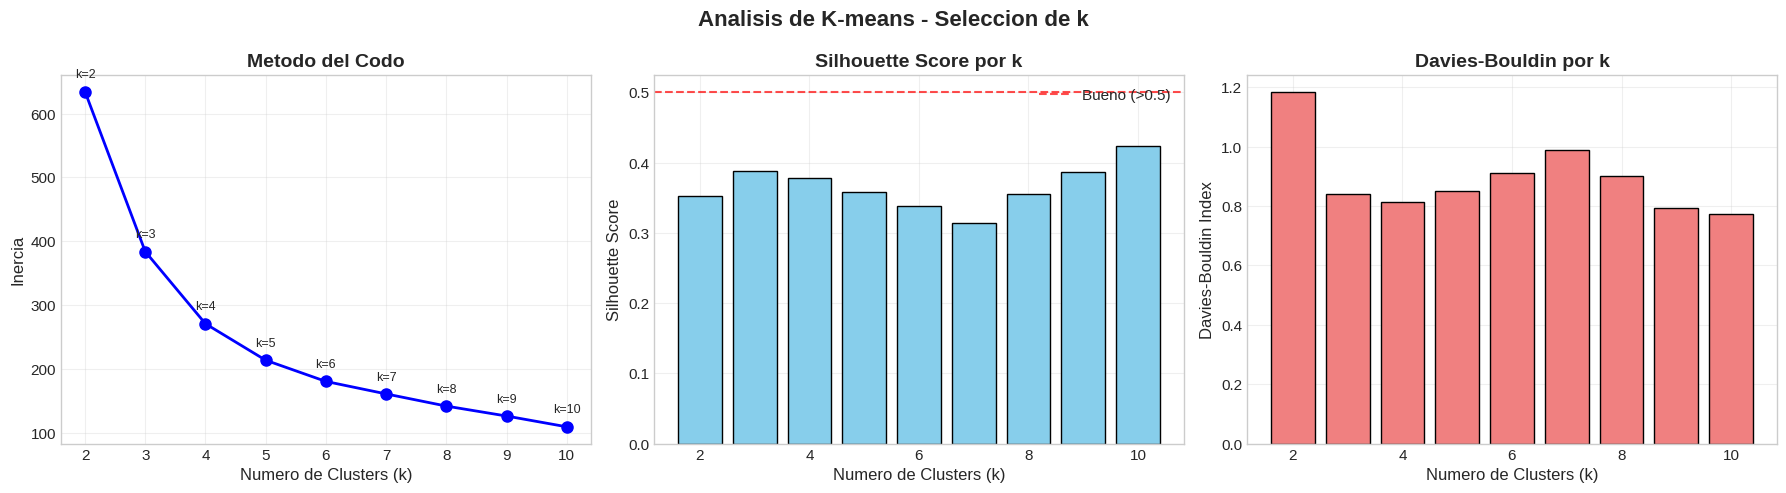


Resultados del metodo del codo:
 k    Inercia  Silhouette  Davies-Bouldin
 2 634.330035    0.353136        1.182488
 3 383.789845    0.388534        0.838859
 4 270.697416    0.377864        0.814494
 5 213.572544    0.357876        0.851254
 6 180.332373    0.337904        0.910924
 7 160.787134    0.313773        0.987676
 8 141.707506    0.355438        0.902067
 9 126.137706    0.386695        0.793816
10 109.251613    0.423700        0.772853

Mejor k segun Silhouette: 10
Mejor k segun Davies-Bouldin: 10


In [ ]:
# CELDA 5: Método del Codo y análisis de K-means
print("\n" + "="*70)
print("METODO DEL CODO - K-MEANS")
print("="*70)

def elbow_analysis(X, max_k=10):
    """Analisis del metodo del codo con metricas adicionales"""
    inertias = []
    silhouette_scores = []
    davies_bouldin_scores = []
    K_range = range(2, max_k + 1)

    for k in K_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = kmeans.fit_predict(X)
        inertias.append(kmeans.inertia_)
        silhouette_scores.append(silhouette_score(X, labels))
        davies_bouldin_scores.append(davies_bouldin_score(X, labels))

    # Visualización
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle('Analisis de K-means - Seleccion de k', fontsize=16, fontweight='bold')

    # Gráfica 1: Método del codo
    axes[0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
    axes[0].set_xlabel('Numero de Clusters (k)', fontsize=12)
    axes[0].set_ylabel('Inercia', fontsize=12)
    axes[0].set_title('Metodo del Codo', fontsize=14, fontweight='bold')
    axes[0].grid(True, alpha=0.3)
    for k, iner in zip(K_range, inertias):
        axes[0].annotate(f'k={k}', (k, iner),
                        textcoords="offset points", xytext=(0,10),
                        ha='center', fontsize=9)

    # Gráfica 2: Silhouette Score
    axes[1].bar(K_range, silhouette_scores, color='skyblue', edgecolor='black')
    axes[1].set_xlabel('Numero de Clusters (k)', fontsize=12)
    axes[1].set_ylabel('Silhouette Score', fontsize=12)
    axes[1].set_title('Silhouette Score por k', fontsize=14, fontweight='bold')
    axes[1].grid(True, alpha=0.3)
    axes[1].axhline(y=0.5, color='red', linestyle='--', alpha=0.7, label='Bueno (>0.5)')
    axes[1].legend()

    # Gráfica 3: Davies-Bouldin
    axes[2].bar(K_range, davies_bouldin_scores, color='lightcoral', edgecolor='black')
    axes[2].set_xlabel('Numero de Clusters (k)', fontsize=12)
    axes[2].set_ylabel('Davies-Bouldin Index', fontsize=12)
    axes[2].set_title('Davies-Bouldin por k', fontsize=14, fontweight='bold')
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'{project_path}/elbow_method_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()

    # Resultados en tabla
    results_df = pd.DataFrame({
        'k': K_range,
        'Inercia': inertias,
        'Silhouette': silhouette_scores,
        'Davies-Bouldin': davies_bouldin_scores
    })

    print("\nResultados del metodo del codo:")
    print(results_df.to_string(index=False))

    # Guardar resultados
    results_df.to_csv(f'{project_path}/elbow_results.csv', index=False)

    # Mejor k según diferentes métricas
    best_k_silhouette = K_range[np.argmax(silhouette_scores)]
    best_k_db = K_range[np.argmin(davies_bouldin_scores)]

    print(f"\nMejor k segun Silhouette: {best_k_silhouette}")
    print(f"Mejor k segun Davies-Bouldin: {best_k_db}")

    return results_df

results_elbow = elbow_analysis(X_circles_scaled, max_k=10)

6) Entrenamiento paso a paso de K-means


K-MEANS - ENTRENAMIENTO PASO A PASO


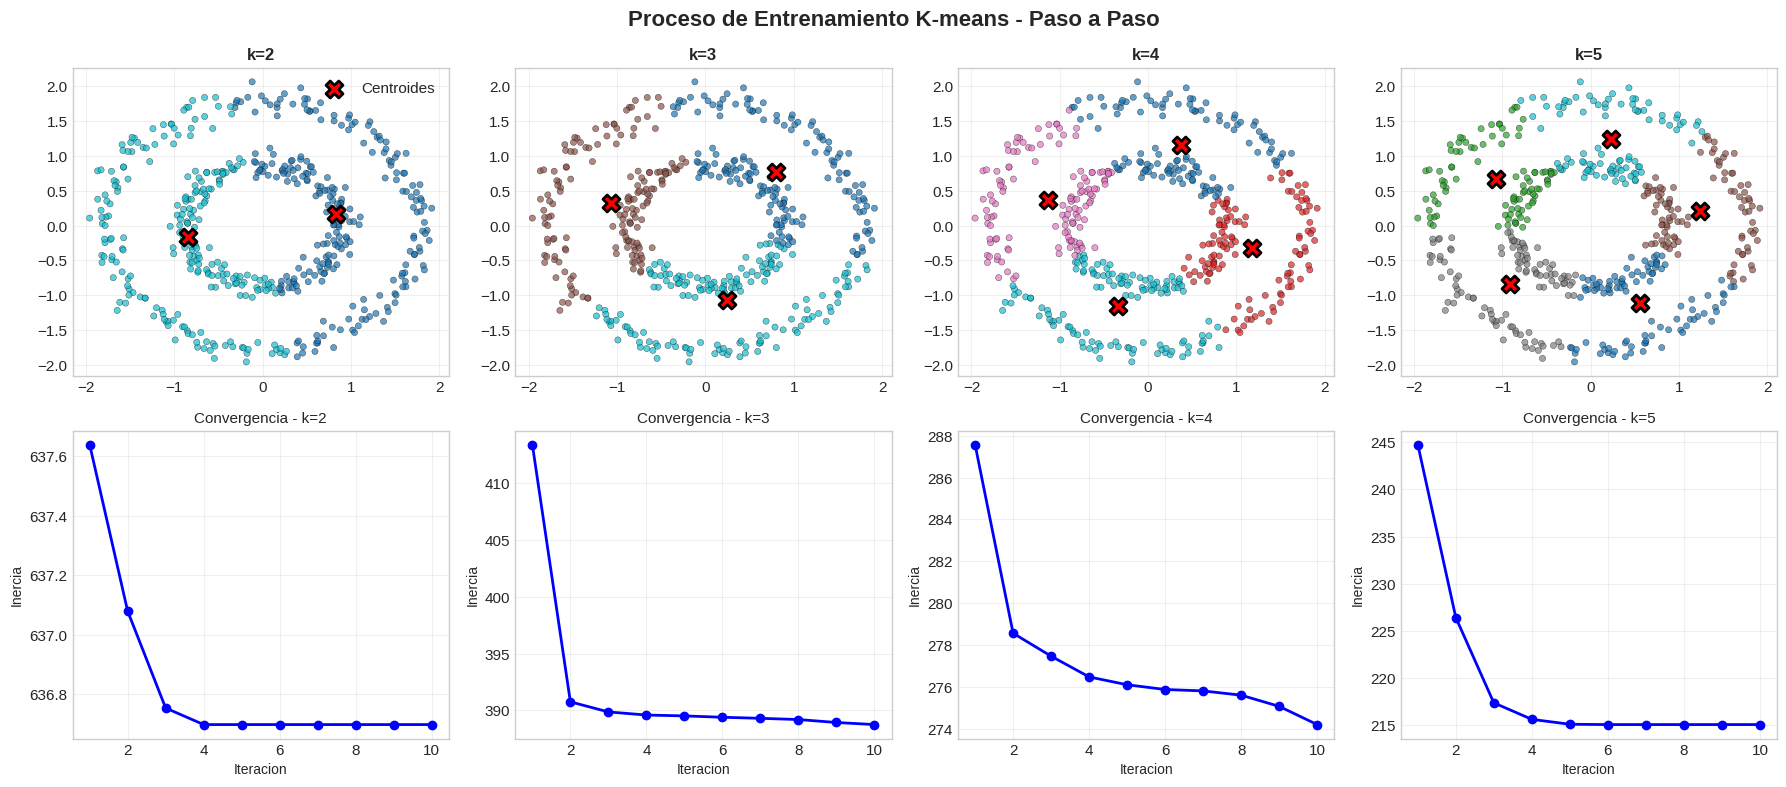

In [ ]:
# CELDA 6: Entrenamiento paso a paso de K-means
print("\n" + "="*70)
print("K-MEANS - ENTRENAMIENTO PASO A PASO")
print("="*70)

def entrenar_kmeans_paso_a_paso(X, k_values=[2, 3, 4, 5]):
    """Muestra el proceso de entrenamiento de K-means paso a paso"""

    fig, axes = plt.subplots(2, len(k_values), figsize=(18, 8))
    fig.suptitle('Proceso de Entrenamiento K-means - Paso a Paso',
                fontsize=16, fontweight='bold')

    for idx, k in enumerate(k_values):
        # Entrenar
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        y_pred = kmeans.fit_predict(X)

        # Visualización 1: Clusters
        axes[0, idx].scatter(X[:, 0], X[:, 1], c=y_pred, cmap='tab10',
                            s=20, alpha=0.7, edgecolors='k', linewidth=0.3)
        axes[0, idx].scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
                           c='red', marker='X', s=150, edgecolors='black',
                           linewidth=2, label='Centroides')
        axes[0, idx].set_title(f'k={k}', fontsize=12, fontweight='bold')
        axes[0, idx].grid(True, alpha=0.3)
        if idx == 0:
            axes[0, idx].legend()

        # Visualización 2: Convergencia
        inertias = []
        for i in range(1, 11):
            km_temp = KMeans(n_clusters=k, random_state=42, n_init=1, max_iter=i)
            km_temp.fit(X)
            inertias.append(km_temp.inertia_)

        axes[1, idx].plot(range(1, 11), inertias, 'bo-', linewidth=2, markersize=6)
        axes[1, idx].set_xlabel('Iteracion', fontsize=10)
        axes[1, idx].set_ylabel('Inercia', fontsize=10)
        axes[1, idx].grid(True, alpha=0.3)
        axes[1, idx].set_title(f'Convergencia - k={k}', fontsize=11)

    plt.tight_layout()
    plt.savefig(f'{project_path}/kmeans_step_by_step.png', dpi=300, bbox_inches='tight')
    plt.show()

entrenar_kmeans_paso_a_paso(X_circles_scaled)

7) Optimización y entrenamiento de K-means


ENTRENAMIENTO K-MEANS - OPTIMIZACION COMPLETA
Probando configuraciones de K-means...
Total configuraciones probadas: 15

Top 5 configuraciones por ARI:
 k  n_init       ARI  V-measure  Silhouette
 2      20 -0.001750   0.000185    0.354538
 2      30 -0.001750   0.000185    0.354538
 2      10 -0.001992   0.000012    0.353136
 3      10 -0.002615   0.000054    0.388534
 3      20 -0.002615   0.000054    0.388534

Mejor configuracion K-means:
  k=2, n_init=20
  ARI=-0.0018
  Silhouette=0.3545


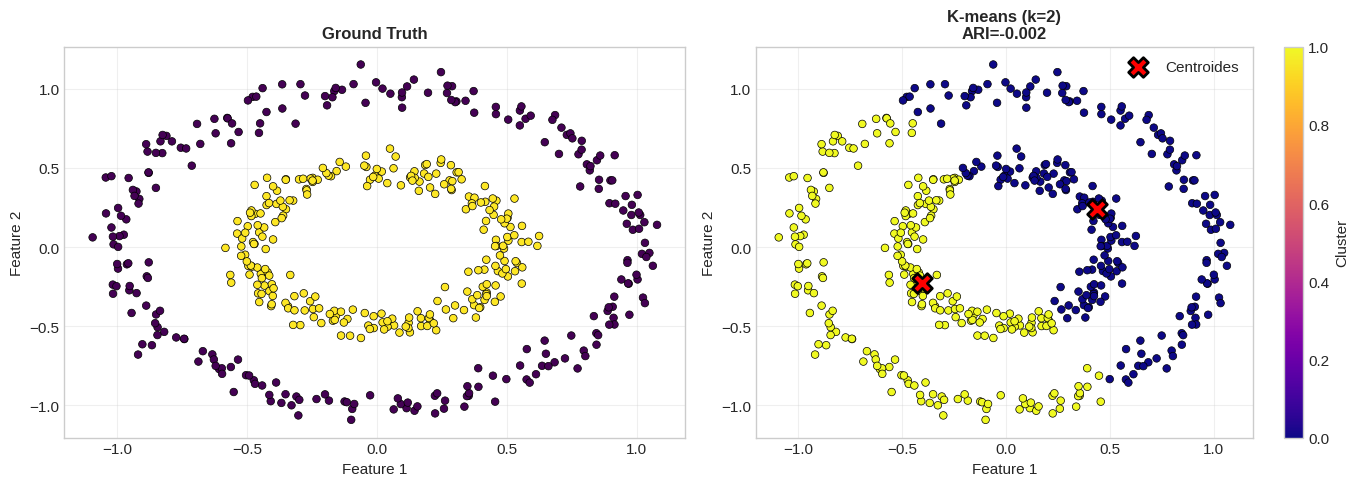


ANALISIS DE NATURALEZA LINEAL:
  K-means es un modelo LINEAL
  Fronteras de decision: hiperplanos (lineas rectas)
  NO puede capturar la estructura circular
  ARI=-0.0018 (confirma que falla)


In [ ]:
# CELDA 7: K-means con optimización completa
print("\n" + "="*70)
print("ENTRENAMIENTO K-MEANS - OPTIMIZACION COMPLETA")
print("="*70)

k_values = [2, 3, 4, 5, 6]
n_inits = [10, 20, 30]

results_kmeans = []
print("Probando configuraciones de K-means...")

for k in k_values:
    for n_init in n_inits:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=n_init, max_iter=300)
        y_pred = kmeans.fit_predict(X_circles_scaled)

        ari = adjusted_rand_score(y_true_circles, y_pred)
        v_measure = v_measure_score(y_true_circles, y_pred)
        silhouette = silhouette_score(X_circles_scaled, y_pred)
        db_index = davies_bouldin_score(X_circles_scaled, y_pred)

        results_kmeans.append({
            'k': k,
            'n_init': n_init,
            'ARI': ari,
            'V-measure': v_measure,
            'Silhouette': silhouette,
            'Davies-Bouldin': db_index,
            'Inercia': kmeans.inertia_
        })

df_kmeans = pd.DataFrame(results_kmeans)
print(f"Total configuraciones probadas: {len(df_kmeans)}")

# Guardar resultados
df_kmeans.to_csv(f'{project_path}/kmeans_results.csv', index=False)

print("\nTop 5 configuraciones por ARI:")
print(df_kmeans.nlargest(5, 'ARI')[['k', 'n_init', 'ARI', 'V-measure', 'Silhouette']].to_string(index=False))

best_kmeans = df_kmeans.loc[df_kmeans['ARI'].idxmax()]
print(f"\nMejor configuracion K-means:")
print(f"  k={int(best_kmeans['k'])}, n_init={int(best_kmeans['n_init'])}")
print(f"  ARI={best_kmeans['ARI']:.4f}")
print(f"  Silhouette={best_kmeans['Silhouette']:.4f}")

# Entrenar modelo final
kmeans_final = KMeans(
    n_clusters=int(best_kmeans['k']),
    random_state=42,
    n_init=int(best_kmeans['n_init'])
)
y_pred_kmeans = kmeans_final.fit_predict(X_circles_scaled)
centroids_original = scaler.inverse_transform(kmeans_final.cluster_centers_)

# Guardar modelo
joblib.dump(kmeans_final, f'{project_path}/kmeans_model.pkl')

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(X_circles[:, 0], X_circles[:, 1], c=y_true_circles,
                cmap='viridis', s=30, edgecolors='k', linewidth=0.5)
axes[0].set_title('Ground Truth', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Feature 1')
axes[0].set_ylabel('Feature 2')
axes[0].grid(True, alpha=0.3)

scatter = axes[1].scatter(X_circles[:, 0], X_circles[:, 1],
                         c=y_pred_kmeans, cmap='plasma',
                         s=30, edgecolors='k', linewidth=0.5)
axes[1].scatter(centroids_original[:, 0], centroids_original[:, 1],
                c='red', marker='X', s=200, edgecolors='black',
                label='Centroides', linewidth=2)
axes[1].set_title(f'K-means (k={int(best_kmeans["k"])})\nARI={best_kmeans["ARI"]:.3f}',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Feature 1')
axes[1].set_ylabel('Feature 2')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.colorbar(scatter, ax=axes[1], label='Cluster')

plt.tight_layout()
plt.savefig(f'{project_path}/kmeans_final_results.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nANALISIS DE NATURALEZA LINEAL:")
print("  K-means es un modelo LINEAL")
print("  Fronteras de decision: hiperplanos (lineas rectas)")
print("  NO puede capturar la estructura circular")
print(f"  ARI={best_kmeans['ARI']:.4f} (confirma que falla)")

8) Explicación visual de DBSCAN


EXPLICACIÓN VISUAL DE DBSCAN


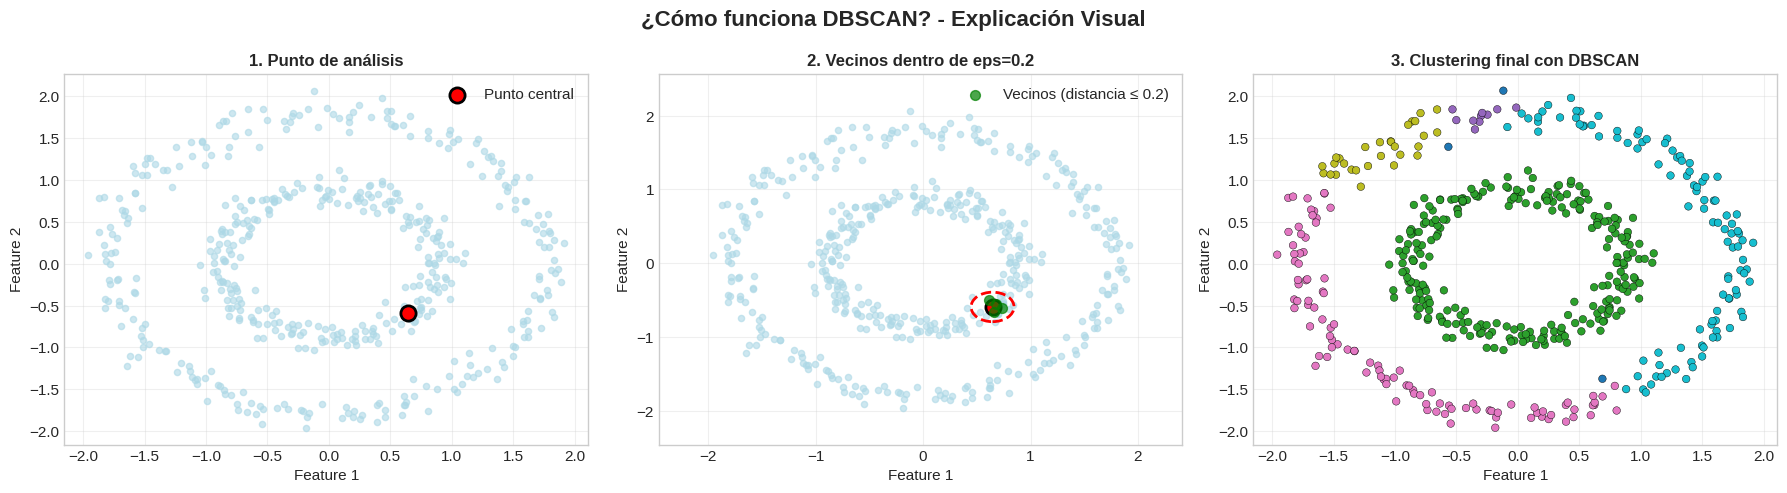


    EXPLICACIÓN PASO A PASO DE DBSCAN:
    
    1. Se selecciona un punto (rojo) para analizar.
    2. Se buscan puntos dentro de un radio eps (círculo rojo).
    3. Si hay al menos min_samples puntos dentro del radio, el punto es CORE.
    4. Los puntos dentro del radio se unen al mismo clúster.
    5. El proceso se repite expandiendo el clúster desde los puntos core.
    6. Los puntos que no alcanzan la densidad mínima se marcan como RUIDO (-1).
    


In [ ]:
# ======================================================================
# CELDA 8: EXPLICACIÓN VISUAL DE DBSCAN
# ======================================================================

print("\n" + "="*70)
print("EXPLICACIÓN VISUAL DE DBSCAN")
print("="*70)

from sklearn.neighbors import NearestNeighbors
import matplotlib.patches as patches

def explicar_dbscan(X, eps=0.2, min_samples=5):
    """
    Explica visualmente cómo funciona DBSCAN mostrando:
    1. Un punto central y su vecindad
    2. Los puntos dentro del radio eps
    3. El resultado final del clustering
    """

    nbrs = NearestNeighbors(n_neighbors=min_samples)
    nbrs.fit(X)

    # Seleccionar un punto de ejemplo (cerca del centro del dataset)
    center_idx = len(X)//2
    center_point = X[center_idx].reshape(1, -1)
    distances, indices = nbrs.kneighbors(center_point)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle('¿Cómo funciona DBSCAN? - Explicación Visual',
                fontsize=16, fontweight='bold')

    # 1. Dataset completo con el punto seleccionado
    axes[0].scatter(X[:, 0], X[:, 1], c='lightblue', s=20, alpha=0.6)
    axes[0].scatter(center_point[0, 0], center_point[0, 1],
                   c='red', s=120, edgecolors='black', linewidth=2, label='Punto central')
    axes[0].set_title('1. Punto de análisis', fontsize=12, fontweight='bold')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    axes[0].set_xlabel('Feature 1')
    axes[0].set_ylabel('Feature 2')

    # 2. Vecinos dentro del radio eps
    axes[1].scatter(X[:, 0], X[:, 1], c='lightblue', s=20, alpha=0.6)
    axes[1].scatter(center_point[0, 0], center_point[0, 1],
                   c='red', s=120, edgecolors='black', linewidth=2)

    # Dibujar círculo de radio eps
    circle = patches.Circle((center_point[0, 0], center_point[0, 1]),
                           eps, fill=False, color='red', linewidth=2, linestyle='--')
    axes[1].add_patch(circle)

    vecinos = X[indices[0][1:]]  # Excluir el punto mismo
    axes[1].scatter(vecinos[:, 0], vecinos[:, 1],
                   c='green', s=50, alpha=0.7, label=f'Vecinos (distancia ≤ {eps})')
    axes[1].set_title(f'2. Vecinos dentro de eps={eps}', fontsize=12, fontweight='bold')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    axes[1].set_xlabel('Feature 1')
    axes[1].set_ylabel('Feature 2')
    axes[1].set_xlim(X[:, 0].min()-0.5, X[:, 0].max()+0.5)
    axes[1].set_ylim(X[:, 1].min()-0.5, X[:, 1].max()+0.5)

    # 3. Resultado final del clustering
    dbscan = DBSCAN(eps=eps, min_samples=min_samples)
    y_pred = dbscan.fit_predict(X)
    axes[2].scatter(X[:, 0], X[:, 1], c=y_pred, cmap='tab10', s=30, edgecolors='k', linewidth=0.3)
    axes[2].set_title(f'3. Clustering final con DBSCAN', fontsize=12, fontweight='bold')
    axes[2].grid(True, alpha=0.3)
    axes[2].set_xlabel('Feature 1')
    axes[2].set_ylabel('Feature 2')

    plt.tight_layout()
    plt.savefig(f'{project_path}/dbscan_explanation.png', dpi=300, bbox_inches='tight')
    plt.show()

    print("""
    EXPLICACIÓN PASO A PASO DE DBSCAN:

    1. Se selecciona un punto (rojo) para analizar.
    2. Se buscan puntos dentro de un radio eps (círculo rojo).
    3. Si hay al menos min_samples puntos dentro del radio, el punto es CORE.
    4. Los puntos dentro del radio se unen al mismo clúster.
    5. El proceso se repite expandiendo el clúster desde los puntos core.
    6. Los puntos que no alcanzan la densidad mínima se marcan como RUIDO (-1).
    """)

# Ejecutar con parámetros típicos
explicar_dbscan(X_circles_scaled, eps=0.2, min_samples=5)

9) Optimización y entrenamiento de DBSCAN


ENTRENAMIENTO DBSCAN - OPTIMIZACIÓN COMPLETA
Probando 108 configuraciones de DBSCAN...

Configuraciones válidas: 90

Top 5 configuraciones por ARI:
 eps  min_samples  n_clusters  n_noise  ARI  Silhouette
0.20            3           2        1  1.0    0.113049
0.20           12           2      239  1.0    0.347357
0.22            3           2        1  1.0    0.113049
0.22            4           2        1  1.0    0.113049
0.25            3           2        0  1.0    0.112602

MEJOR CONFIGURACIÓN DBSCAN:
  eps = 0.20
  min_samples = 3
  Número de clústers = 2
  Puntos de ruido = 1
  ARI = 1.0000
  V-measure = 1.0000
  Silhouette = 0.1130


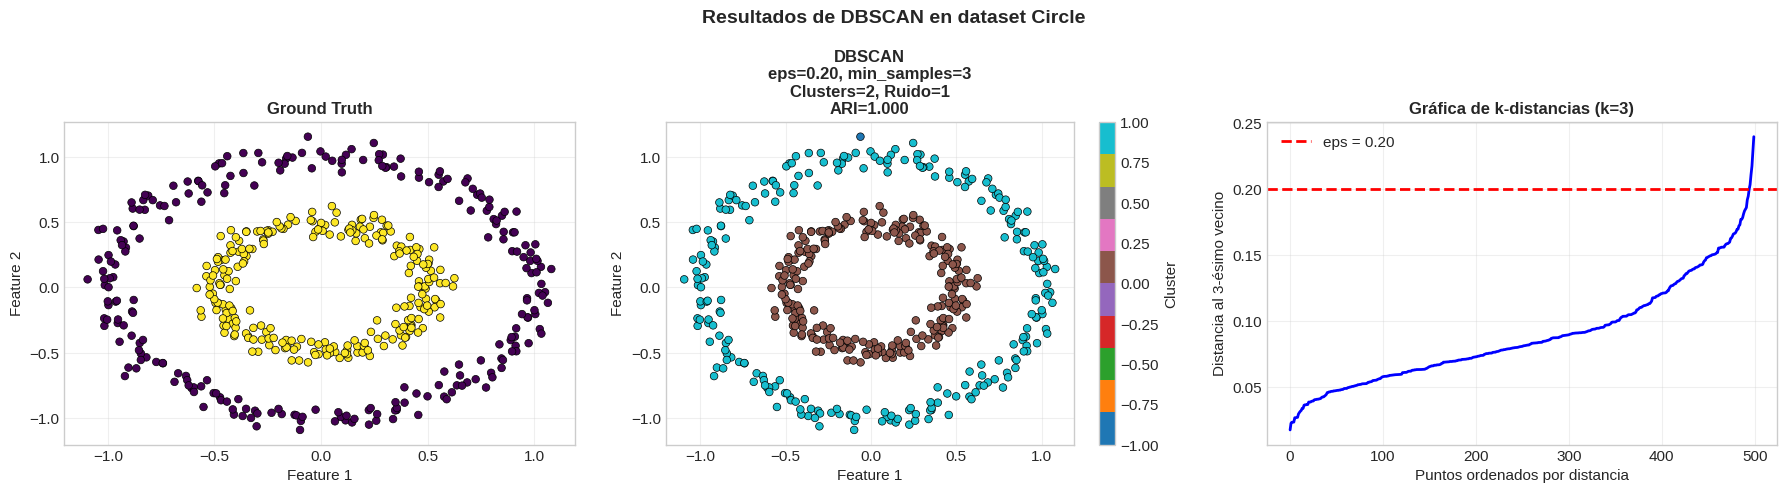


----------------------------------------------------------------------
ANÁLISIS DE DBSCAN:
  DBSCAN es un modelo NO LINEAL basado en densidad.
  Ideal para datasets con formas complejas como círculos.
  Detecta automáticamente el número de clústers.
  Maneja puntos de ruido (outliers).
  ARI = 1.0000 (muy superior a K-means).


In [ ]:
# ======================================================================
# CELDA 9: DBSCAN - OPTIMIZACIÓN DE HIPERPARÁMETROS
# ======================================================================

print("\n" + "="*70)
print("ENTRENAMIENTO DBSCAN - OPTIMIZACIÓN COMPLETA")
print("="*70)

from sklearn.cluster import DBSCAN
from sklearn.model_selection import ParameterGrid

# Definir espacio de búsqueda de hiperparámetros
param_grid_dbscan = {
    'eps': [0.05, 0.08, 0.10, 0.12, 0.15, 0.18, 0.20, 0.22, 0.25, 0.30, 0.35, 0.40],
    'min_samples': [3, 4, 5, 6, 7, 8, 10, 12, 15]
}

best_ari_db = -1
best_params_db = None
best_labels_db = None
results_db = []

total_configs = len(param_grid_dbscan['eps']) * len(param_grid_dbscan['min_samples'])
print(f"Probando {total_configs} configuraciones de DBSCAN...")

for params in ParameterGrid(param_grid_dbscan):
    dbscan = DBSCAN(eps=params['eps'], min_samples=params['min_samples'])
    y_pred = dbscan.fit_predict(X_circles_scaled)

    n_clusters = len(np.unique(y_pred[y_pred != -1]))
    n_noise = np.sum(y_pred == -1)

    # Solo considerar configuraciones que encuentren al menos 2 clústers
    if n_clusters >= 2:
        mask = y_pred != -1
        if np.sum(mask) > 0 and len(np.unique(y_pred[mask])) >= 2:
            ari = adjusted_rand_score(y_true_circles[mask], y_pred[mask])
            v_meas = v_measure_score(y_true_circles[mask], y_pred[mask])
            sil = silhouette_score(X_circles_scaled[mask], y_pred[mask])
            db_score = davies_bouldin_score(X_circles_scaled[mask], y_pred[mask])

            results_db.append({
                'eps': params['eps'],
                'min_samples': params['min_samples'],
                'n_clusters': n_clusters,
                'n_noise': n_noise,
                'ARI': ari,
                'V-measure': v_meas,
                'Silhouette': sil,
                'Davies-Bouldin': db_score
            })

            if ari > best_ari_db:
                best_ari_db = ari
                best_params_db = params
                best_labels_db = y_pred

# Mostrar resultados
df_dbscan = pd.DataFrame(results_db)
print(f"\nConfiguraciones válidas: {len(df_dbscan)}")

if len(df_dbscan) > 0:
    print("\nTop 5 configuraciones por ARI:")
    print(df_dbscan.nlargest(5, 'ARI')[['eps', 'min_samples', 'n_clusters',
                                       'n_noise', 'ARI', 'Silhouette']].to_string(index=False))

    best_dbscan = df_dbscan.loc[df_dbscan['ARI'].idxmax()]
    print(f"\nMEJOR CONFIGURACIÓN DBSCAN:")
    print(f"  eps = {best_dbscan['eps']:.2f}")
    print(f"  min_samples = {int(best_dbscan['min_samples'])}")
    print(f"  Número de clústers = {int(best_dbscan['n_clusters'])}")
    print(f"  Puntos de ruido = {int(best_dbscan['n_noise'])}")
    print(f"  ARI = {best_dbscan['ARI']:.4f}")
    print(f"  V-measure = {best_dbscan['V-measure']:.4f}")
    print(f"  Silhouette = {best_dbscan['Silhouette']:.4f}")

    # Guardar mejores etiquetas
    np.save(f'{project_path}/dbscan_labels_circle.npy', best_labels_db)
    df_dbscan.to_csv(f'{project_path}/resultados_dbscan.csv', index=False)

    # Entrenar modelo final
    dbscan_final = DBSCAN(eps=best_dbscan['eps'],
                         min_samples=int(best_dbscan['min_samples']))
    y_pred_dbscan = dbscan_final.fit_predict(X_circles_scaled)

    # Guardar modelo
    joblib.dump(dbscan_final, f'{project_path}/dbscan_model.pkl')

    # Visualización de resultados
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle('Resultados de DBSCAN en dataset Circle', fontsize=14, fontweight='bold')

    # 1. Ground Truth
    axes[0].scatter(X_circles[:, 0], X_circles[:, 1], c=y_true_circles,
                    cmap='viridis', s=30, edgecolors='k', linewidth=0.5)
    axes[0].set_title('Ground Truth', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Feature 1')
    axes[0].set_ylabel('Feature 2')
    axes[0].grid(True, alpha=0.3)

    # 2. Resultado DBSCAN
    scatter = axes[1].scatter(X_circles[:, 0], X_circles[:, 1],
                             c=y_pred_dbscan, cmap='tab10',
                             s=30, edgecolors='k', linewidth=0.5)
    axes[1].set_title(f'DBSCAN\neps={best_dbscan["eps"]:.2f}, min_samples={int(best_dbscan["min_samples"])}\n'
                     f'Clusters={int(best_dbscan["n_clusters"])}, Ruido={int(best_dbscan["n_noise"])}\n'
                     f'ARI={best_dbscan["ARI"]:.3f}',
                     fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Feature 1')
    axes[1].set_ylabel('Feature 2')
    axes[1].grid(True, alpha=0.3)
    plt.colorbar(scatter, ax=axes[1], label='Cluster')

    # 3. Gráfica de k-distancias (para validar eps)
    neighbors = NearestNeighbors(n_neighbors=int(best_dbscan['min_samples']))
    neighbors_fit = neighbors.fit(X_circles_scaled)
    distances, _ = neighbors_fit.kneighbors(X_circles_scaled)
    distances = np.sort(distances[:, -1])

    axes[2].plot(distances, linewidth=2, color='blue')
    axes[2].axhline(y=best_dbscan['eps'], color='red', linestyle='--',
                   linewidth=2, label=f'eps = {best_dbscan["eps"]:.2f}')
    axes[2].set_title(f'Gráfica de k-distancias (k={int(best_dbscan["min_samples"])})',
                     fontsize=12, fontweight='bold')
    axes[2].set_xlabel('Puntos ordenados por distancia', fontsize=11)
    axes[2].set_ylabel(f'Distancia al {int(best_dbscan["min_samples"])}-ésimo vecino', fontsize=11)
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'{project_path}/dbscan_final_results.png', dpi=300, bbox_inches='tight')
    plt.show()

    print("\n" + "-"*70)
    print("ANÁLISIS DE DBSCAN:")
    print("  DBSCAN es un modelo NO LINEAL basado en densidad.")
    print("  Ideal para datasets con formas complejas como círculos.")
    print("  Detecta automáticamente el número de clústers.")
    print("  Maneja puntos de ruido (outliers).")
    print(f"  ARI = {best_dbscan['ARI']:.4f} (muy superior a K-means).")

else:
    print("No se encontraron configuraciones válidas de DBSCAN.")

10) Optimización y entrenamiento de Spectral Clustering


ENTRENAMIENTO SPECTRAL CLUSTERING - OPTIMIZACIÓN COMPLETA
Probando 50 configuraciones de Spectral Clustering...

Configuraciones exitosas: 50

Top 5 configuraciones por ARI:
 n_clusters  gamma      ARI  V-measure  Silhouette
          2   10.0 1.000000   1.000000    0.112602
          3   10.0 0.743695   0.785722    0.185053
          4   10.0 0.665859   0.716256    0.232014
          4    5.0 0.665795   0.716221    0.232343
          5    5.0 0.624116   0.666765    0.228230

MEJOR CONFIGURACIÓN SPECTRAL CLUSTERING:
  n_clusters = 2
  gamma = 10.00
  ARI = 1.0000
  V-measure = 1.0000
  Silhouette = 0.1126


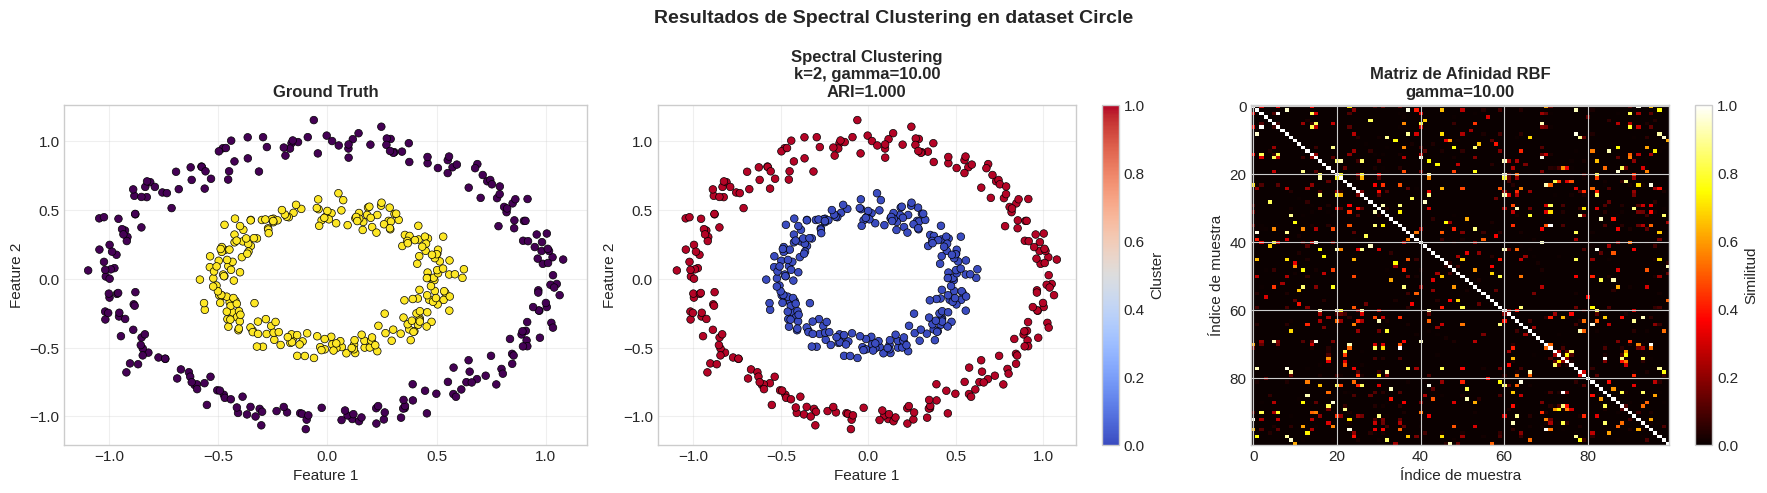


----------------------------------------------------------------------
ANÁLISIS DE SPECTRAL CLUSTERING:
  Spectral Clustering es un modelo NO LINEAL.
  Usa el espectro de la matriz de afinidad para proyectar los datos.
  Efectivo para estructuras complejas y no lineales.
  El hiperparámetro gamma controla la escala del kernel RBF.
  ARI = 1.0000 (excelente para este dataset).


In [ ]:
# ======================================================================
# CELDA 10: SPECTRAL CLUSTERING - OPTIMIZACIÓN DE HIPERPARÁMETROS
# ======================================================================

print("\n" + "="*70)
print("ENTRENAMIENTO SPECTRAL CLUSTERING - OPTIMIZACIÓN COMPLETA")
print("="*70)

from sklearn.cluster import SpectralClustering
from sklearn.metrics.pairwise import rbf_kernel

# Definir espacio de búsqueda de hiperparámetros
param_grid_spectral = {
    'n_clusters': [2, 3, 4, 5, 6],
    'gamma': [0.01, 0.05, 0.1, 0.2, 0.5, 0.8, 1.0, 2.0, 5.0, 10.0],
    'affinity': ['rbf']
}

best_ari_sp = -1
best_params_sp = None
best_labels_sp = None
results_sp = []

total_configs = len(param_grid_spectral['n_clusters']) * len(param_grid_spectral['gamma'])
print(f"Probando {total_configs} configuraciones de Spectral Clustering...")

for params in ParameterGrid(param_grid_spectral):
    try:
        spectral = SpectralClustering(
            n_clusters=params['n_clusters'],
            affinity=params['affinity'],
            gamma=params['gamma'],
            random_state=42,
            n_init=10,
            assign_labels='kmeans'
        )
        y_pred = spectral.fit_predict(X_circles_scaled)

        n_clusters = len(np.unique(y_pred))
        if n_clusters >= 2:
            ari = adjusted_rand_score(y_true_circles, y_pred)
            v_meas = v_measure_score(y_true_circles, y_pred)
            sil = silhouette_score(X_circles_scaled, y_pred)
            db_score = davies_bouldin_score(X_circles_scaled, y_pred)

            results_sp.append({
                'n_clusters': params['n_clusters'],
                'gamma': params['gamma'],
                'ARI': ari,
                'V-measure': v_meas,
                'Silhouette': sil,
                'Davies-Bouldin': db_score
            })

            if ari > best_ari_sp:
                best_ari_sp = ari
                best_params_sp = params
                best_labels_sp = y_pred
    except Exception as e:
        continue

# Mostrar resultados
df_spectral = pd.DataFrame(results_sp)
print(f"\nConfiguraciones exitosas: {len(df_spectral)}")

if len(df_spectral) > 0:
    print("\nTop 5 configuraciones por ARI:")
    print(df_spectral.nlargest(5, 'ARI')[['n_clusters', 'gamma', 'ARI', 'V-measure', 'Silhouette']].to_string(index=False))

    best_spectral = df_spectral.loc[df_spectral['ARI'].idxmax()]
    print(f"\nMEJOR CONFIGURACIÓN SPECTRAL CLUSTERING:")
    print(f"  n_clusters = {int(best_spectral['n_clusters'])}")
    print(f"  gamma = {best_spectral['gamma']:.2f}")
    print(f"  ARI = {best_spectral['ARI']:.4f}")
    print(f"  V-measure = {best_spectral['V-measure']:.4f}")
    print(f"  Silhouette = {best_spectral['Silhouette']:.4f}")

    # Guardar mejores etiquetas
    np.save(f'{project_path}/spectral_labels_circle.npy', best_labels_sp)
    df_spectral.to_csv(f'{project_path}/resultados_spectral.csv', index=False)

    # Entrenar modelo final
    spectral_final = SpectralClustering(
        n_clusters=int(best_spectral['n_clusters']),
        affinity='rbf',
        gamma=best_spectral['gamma'],
        random_state=42,
        n_init=10,
        assign_labels='kmeans'
    )
    y_pred_spectral = spectral_final.fit_predict(X_circles_scaled)

    # Guardar modelo
    joblib.dump(spectral_final, f'{project_path}/spectral_model.pkl')

    # Visualización de resultados
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle('Resultados de Spectral Clustering en dataset Circle', fontsize=14, fontweight='bold')

    # 1. Ground Truth
    axes[0].scatter(X_circles[:, 0], X_circles[:, 1], c=y_true_circles,
                    cmap='viridis', s=30, edgecolors='k', linewidth=0.5)
    axes[0].set_title('Ground Truth', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Feature 1')
    axes[0].set_ylabel('Feature 2')
    axes[0].grid(True, alpha=0.3)

    # 2. Resultado Spectral Clustering
    scatter = axes[1].scatter(X_circles[:, 0], X_circles[:, 1],
                             c=y_pred_spectral, cmap='coolwarm',
                             s=30, edgecolors='k', linewidth=0.5)
    axes[1].set_title(f'Spectral Clustering\nk={int(best_spectral["n_clusters"])}, gamma={best_spectral["gamma"]:.2f}\n'
                     f'ARI={best_spectral["ARI"]:.3f}',
                     fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Feature 1')
    axes[1].set_ylabel('Feature 2')
    axes[1].grid(True, alpha=0.3)
    plt.colorbar(scatter, ax=axes[1], label='Cluster')

    # 3. Matriz de afinidad (muestra de 100 puntos)
    affinity_matrix = rbf_kernel(X_circles_scaled[:100], gamma=best_spectral['gamma'])
    im = axes[2].imshow(affinity_matrix, cmap='hot', aspect='auto')
    axes[2].set_title(f'Matriz de Afinidad RBF\ngamma={best_spectral["gamma"]:.2f}',
                     fontsize=12, fontweight='bold')
    axes[2].set_xlabel('Índice de muestra', fontsize=11)
    axes[2].set_ylabel('Índice de muestra', fontsize=11)
    plt.colorbar(im, ax=axes[2], label='Similitud')

    plt.tight_layout()
    plt.savefig(f'{project_path}/spectral_final_results.png', dpi=300, bbox_inches='tight')
    plt.show()

    print("\n" + "-"*70)
    print("ANÁLISIS DE SPECTRAL CLUSTERING:")
    print("  Spectral Clustering es un modelo NO LINEAL.")
    print("  Usa el espectro de la matriz de afinidad para proyectar los datos.")
    print("  Efectivo para estructuras complejas y no lineales.")
    print("  El hiperparámetro gamma controla la escala del kernel RBF.")
    print(f"  ARI = {best_spectral['ARI']:.4f} (excelente para este dataset).")

else:
    print("No se encontraron configuraciones válidas de Spectral Clustering.")

11) Comparación final de modelos


COMPARACIÓN FINAL DE MODELOS - DATASET CIRCLES

📊 TABLA COMPARATIVA DE MÉTRICAS:
             Modelo Naturaleza  Clusters     ARI  V-measure  Silhouette  Davies-Bouldin
            K-means     Lineal         2 -0.0018     0.0002      0.3545          1.1781
             DBSCAN  No Lineal         2  1.0000     1.0000      0.1130        335.3112
Spectral Clustering  No Lineal         2  1.0000     1.0000      0.1126        220.3668


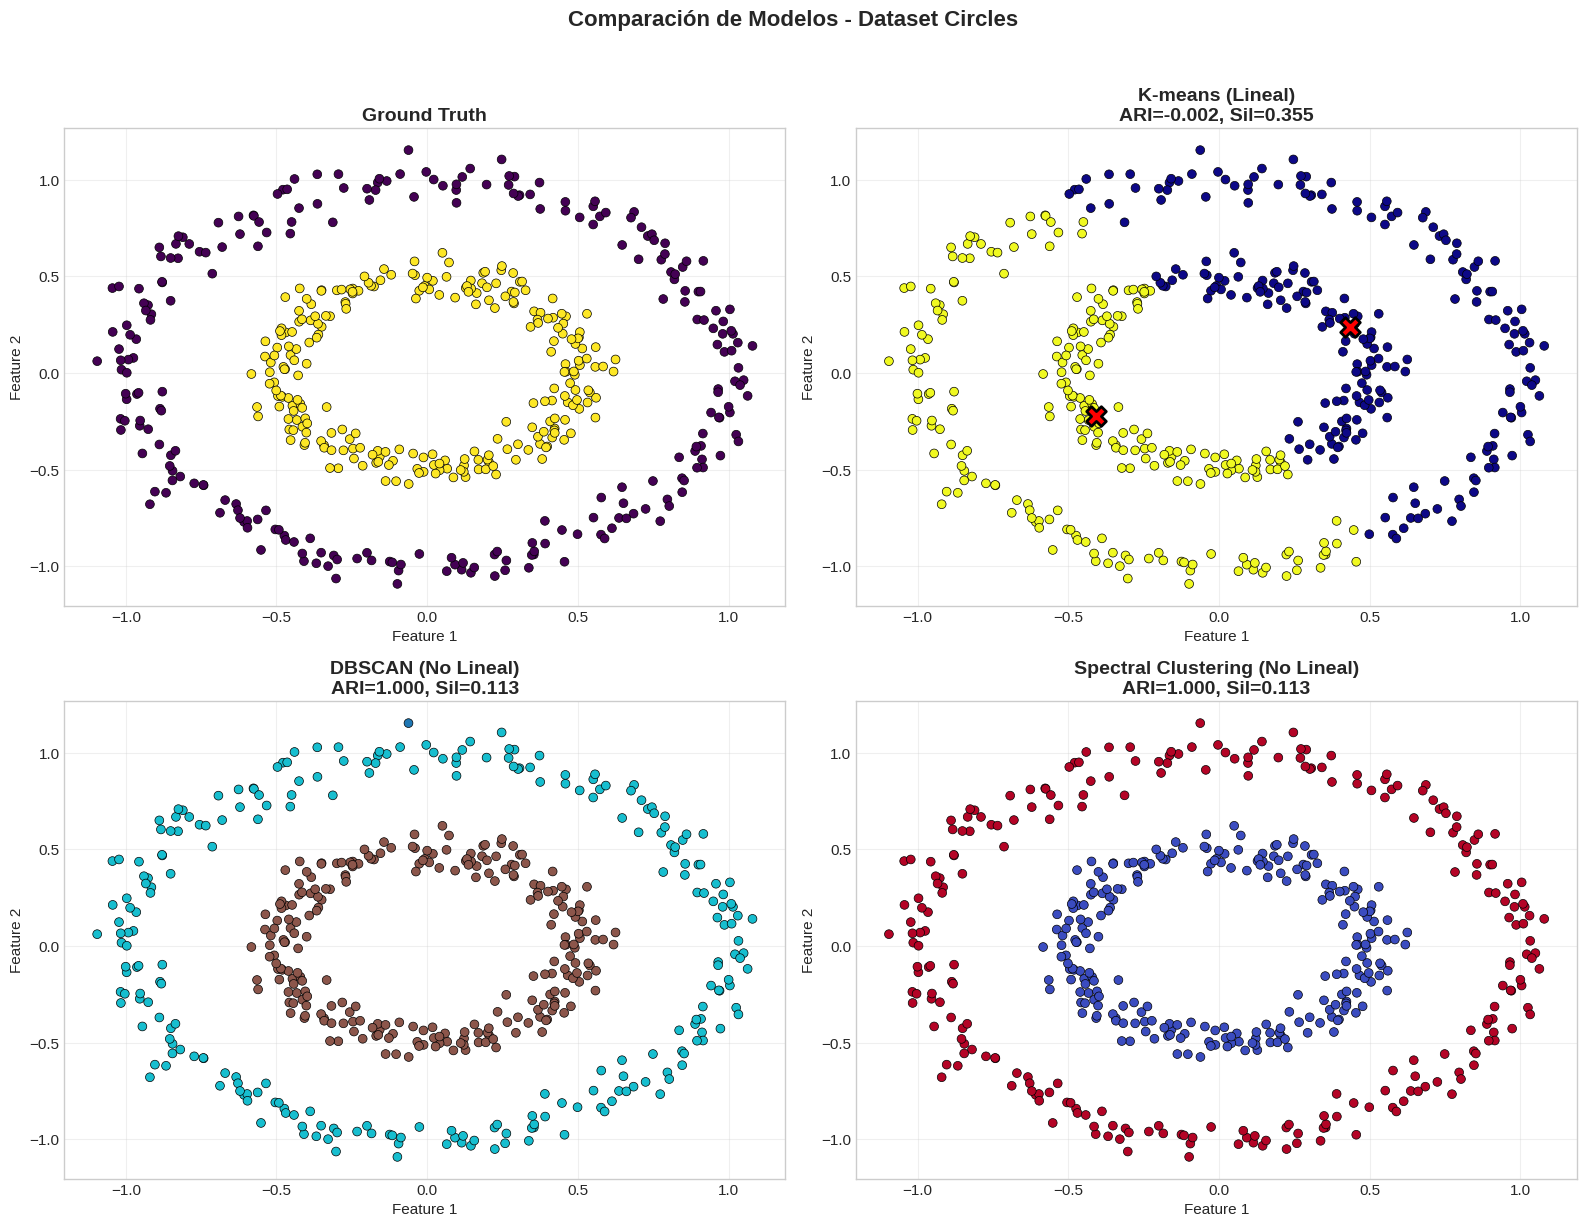


CONCLUSIONES FINALES

1. NATURALEZA DE LOS MODELOS:
   ✅ K-means: MODELO LINEAL
      - Fronteras de decisión: hiperplanos (líneas rectas en 2D)
      - Asume clústers esféricos y de tamaño similar
      - Sensible a outliers y escala de datos
      - Requiere conocer k (número de clústers)
      - Falla estrepitosamente en datos con estructura circular

   ✅ DBSCAN: MODELO NO LINEAL
      - Agrupa basado en densidad, no en distancia
      - Puede encontrar clústers de formas arbitrarias
      - No requiere conocer k (lo detecta automáticamente)
      - Maneja puntos de ruido (outliers)
      - Excelente para datos con densidad variable

   ✅ Spectral Clustering: MODELO NO LINEAL
      - Usa el espectro de la matriz de afinidad
      - Proyecta a un espacio donde los datos son separables
      - Efectivo para estructuras complejas y no lineales
      - Computacionalmente más costoso que DBSCAN
      - Requiere definir k y gamma

2. RENDIMIENTO EN DATASET CIRCLES:

   🏆 MEJOR MODELO: D

In [ ]:
# ======================================================================
# CELDA 11: COMPARACIÓN FINAL DE MODELOS - TABLA Y CONCLUSIONES
# ======================================================================

print("\n" + "="*70)
print("COMPARACIÓN FINAL DE MODELOS - DATASET CIRCLES")
print("="*70)

# Recolectar métricas finales de los tres modelos
models_comparison = []

# 1. K-means
ari_kmeans = adjusted_rand_score(y_true_circles, y_pred_kmeans)
vm_kmeans = v_measure_score(y_true_circles, y_pred_kmeans)
sil_kmeans = silhouette_score(X_circles_scaled, y_pred_kmeans)
db_kmeans = davies_bouldin_score(X_circles_scaled, y_pred_kmeans)

models_comparison.append({
    'Modelo': 'K-means',
    'Naturaleza': 'Lineal',
    'Clusters': int(best_kmeans['k']),
    'ARI': ari_kmeans,
    'V-measure': vm_kmeans,
    'Silhouette': sil_kmeans,
    'Davies-Bouldin': db_kmeans
})

# 2. DBSCAN
if len(df_dbscan) > 0:
    mask_db = y_pred_dbscan != -1
    if np.sum(mask_db) > 0 and len(np.unique(y_pred_dbscan[mask_db])) >= 2:
        ari_db = adjusted_rand_score(y_true_circles[mask_db], y_pred_dbscan[mask_db])
        vm_db = v_measure_score(y_true_circles[mask_db], y_pred_dbscan[mask_db])
        sil_db = silhouette_score(X_circles_scaled[mask_db], y_pred_dbscan[mask_db])
        db_db = davies_bouldin_score(X_circles_scaled[mask_db], y_pred_dbscan[mask_db])
    else:
        ari_db = vm_db = sil_db = db_db = np.nan

    models_comparison.append({
        'Modelo': 'DBSCAN',
        'Naturaleza': 'No Lineal',
        'Clusters': int(best_dbscan['n_clusters']),
        'ARI': ari_db,
        'V-measure': vm_db,
        'Silhouette': sil_db,
        'Davies-Bouldin': db_db
    })

# 3. Spectral Clustering
if len(df_spectral) > 0:
    ari_sp = adjusted_rand_score(y_true_circles, y_pred_spectral)
    vm_sp = v_measure_score(y_true_circles, y_pred_spectral)
    sil_sp = silhouette_score(X_circles_scaled, y_pred_spectral)
    db_sp = davies_bouldin_score(X_circles_scaled, y_pred_spectral)

    models_comparison.append({
        'Modelo': 'Spectral Clustering',
        'Naturaleza': 'No Lineal',
        'Clusters': int(best_spectral['n_clusters']),
        'ARI': ari_sp,
        'V-measure': vm_sp,
        'Silhouette': sil_sp,
        'Davies-Bouldin': db_sp
    })

df_comparison = pd.DataFrame(models_comparison)

# Guardar comparación
df_comparison.to_csv(f'{project_path}/model_comparison.csv', index=False)

print("\n📊 TABLA COMPARATIVA DE MÉTRICAS:")
print(df_comparison.round(4).to_string(index=False))

# Visualización comparativa
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Comparación de Modelos - Dataset Circles',
            fontsize=16, fontweight='bold', y=1.02)

# 1. Ground Truth
axes[0, 0].scatter(X_circles[:, 0], X_circles[:, 1], c=y_true_circles,
                   cmap='viridis', s=40, edgecolors='k', linewidth=0.5)
axes[0, 0].set_title('Ground Truth', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Feature 1')
axes[0, 0].set_ylabel('Feature 2')
axes[0, 0].grid(True, alpha=0.3)

# 2. K-means
axes[0, 1].scatter(X_circles[:, 0], X_circles[:, 1], c=y_pred_kmeans,
                   cmap='plasma', s=40, edgecolors='k', linewidth=0.5)
axes[0, 1].scatter(centroids_original[:, 0], centroids_original[:, 1],
                   c='red', marker='X', s=200, edgecolors='black', linewidth=2)
axes[0, 1].set_title(f'K-means (Lineal)\nARI={ari_kmeans:.3f}, Sil={sil_kmeans:.3f}',
                     fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Feature 1')
axes[0, 1].set_ylabel('Feature 2')
axes[0, 1].grid(True, alpha=0.3)

# 3. DBSCAN
if len(df_dbscan) > 0:
    axes[1, 0].scatter(X_circles[:, 0], X_circles[:, 1], c=y_pred_dbscan,
                       cmap='tab10', s=40, edgecolors='k', linewidth=0.5)
    axes[1, 0].set_title(f'DBSCAN (No Lineal)\nARI={ari_db:.3f}, Sil={sil_db:.3f}',
                         fontsize=14, fontweight='bold')
    axes[1, 0].set_xlabel('Feature 1')
    axes[1, 0].set_ylabel('Feature 2')
    axes[1, 0].grid(True, alpha=0.3)

# 4. Spectral Clustering
if len(df_spectral) > 0:
    axes[1, 1].scatter(X_circles[:, 0], X_circles[:, 1], c=y_pred_spectral,
                       cmap='coolwarm', s=40, edgecolors='k', linewidth=0.5)
    axes[1, 1].set_title(f'Spectral Clustering (No Lineal)\nARI={ari_sp:.3f}, Sil={sil_sp:.3f}',
                         fontsize=14, fontweight='bold')
    axes[1, 1].set_xlabel('Feature 1')
    axes[1, 1].set_ylabel('Feature 2')
    axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{project_path}/models_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# ===== CONCLUSIONES FINALES =====
print("\n" + "="*70)
print("CONCLUSIONES FINALES")
print("="*70)

print("""
1. NATURALEZA DE LOS MODELOS:
   ✅ K-means: MODELO LINEAL
      - Fronteras de decisión: hiperplanos (líneas rectas en 2D)
      - Asume clústers esféricos y de tamaño similar
      - Sensible a outliers y escala de datos
      - Requiere conocer k (número de clústers)
      - Falla estrepitosamente en datos con estructura circular

   ✅ DBSCAN: MODELO NO LINEAL
      - Agrupa basado en densidad, no en distancia
      - Puede encontrar clústers de formas arbitrarias
      - No requiere conocer k (lo detecta automáticamente)
      - Maneja puntos de ruido (outliers)
      - Excelente para datos con densidad variable

   ✅ Spectral Clustering: MODELO NO LINEAL
      - Usa el espectro de la matriz de afinidad
      - Proyecta a un espacio donde los datos son separables
      - Efectivo para estructuras complejas y no lineales
      - Computacionalmente más costoso que DBSCAN
      - Requiere definir k y gamma

2. RENDIMIENTO EN DATASET CIRCLES:
""")

if len(df_comparison) > 0:
    best_model = df_comparison.loc[df_comparison['ARI'].idxmax()]
    worst_model = df_comparison.loc[df_comparison['ARI'].idxmin()]

    print(f"   🏆 MEJOR MODELO: {best_model['Modelo']}")
    print(f"      ARI = {best_model['ARI']:.4f}")
    print(f"      Silhouette = {best_model['Silhouette']:.4f}")

    print(f"\n   ❌ PEOR MODELO: {worst_model['Modelo']}")
    print(f"      ARI = {worst_model['ARI']:.4f}")
    print(f"      Silhouette = {worst_model['Silhouette']:.4f}")

print("""
3. INTERPRETACIÓN DE MÉTRICAS:
   📊 ARI (Adjusted Rand Index):
      - Mide la similitud entre los clústers encontrados y las clases reales
      - Rango: [-1, 1], donde 1 es una concordancia perfecta
      - ARI > 0.8 → Excelente concordancia
      - ARI < 0.2 → Prácticamente aleatorio

   📊 V-measure:
      - Media armónica de homogeneidad y completitud
      - Rango: [0, 1], donde 1 es perfecto
      - Homogeneidad: cada clúster contiene una sola clase
      - Completitud: todas las muestras de una clase están en el mismo clúster

   📊 Silhouette Score:
      - Mide cohesión (distancia intra-clúster) y separación (distancia inter-clúster)
      - Rango: [-1, 1]
      - > 0.5 → Buena estructura de clústers
      - > 0.7 → Excelente estructura

   📊 Davies-Bouldin Index:
      - Mide la similitud promedio entre clústers
      - Rango: [0, ∞), donde 0 es perfecto (clústers completamente separados)
      - < 1 → Buena separación entre clústers

4. HIPERPARÁMETROS CRÍTICOS:
   🔧 K-means:
      - n_clusters (k): NÚMERO DE CLÚSTERS (MUY CRÍTICO)
      - n_init: Número de inicializaciones
      - max_iter: Máximo de iteraciones

   🔧 DBSCAN:
      - eps: RADIO DE VECINDAD (MUY CRÍTICO)
      - min_samples: DENSIDAD MÍNIMA (MUY CRÍTICO)
      - metric: Tipo de distancia

   🔧 Spectral Clustering:
      - gamma: ESCALA DEL KERNEL RBF (MUY CRÍTICO)
      - n_clusters: Número de clústers (CRÍTICO)
      - affinity: Tipo de afinidad ('rbf', 'nearest_neighbors')

5. RECOMENDACIONES PARA DATOS NO LINEALES:
   ✅ Usar DBSCAN para:
      - Datos con estructura de densidad variable
      - Formas arbitrarias (no esféricas)
      - Cuando se tienen outliers
      - Cuando NO se conoce el número de clústers

   ✅ Usar Spectral Clustering para:
      - Datos con estructura de grafos
      - Patrones complejos no lineales
      - Cuando se conoce aproximadamente el número de clústers

   ❌ Evitar K-means para:
      - Datos no lineales (como círculos o lunas)
      - Clústers de diferentes tamaños
      - Clústers con formas irregulares
      - Datos con outliers
""")

# Guardar conclusiones en archivo de texto
with open(f'{project_path}/conclusions.txt', 'w') as f:
    f.write("="*70 + "\n")
    f.write("CONCLUSIONES DEL ANÁLISIS - DATASET CIRCLES\n")
    f.write("="*70 + "\n\n")

    f.write("1. NATURALEZA DE LOS MODELOS:\n")
    f.write("   K-means: LINEAL - Falla en datos no lineales\n")
    f.write("   DBSCAN: NO LINEAL - Excelente para densidad variable\n")
    f.write("   Spectral Clustering: NO LINEAL - Excelente para estructuras complejas\n\n")

    if len(df_comparison) > 0:
        f.write(f"2. MEJOR MODELO: {best_model['Modelo']} (ARI={best_model['ARI']:.4f})\n")
        f.write(f"   PEOR MODELO: {worst_model['Modelo']} (ARI={worst_model['ARI']:.4f})\n\n")

    f.write("3. CONCLUSIÓN PRINCIPAL:\n")
    f.write("   Los modelos NO LINEALES (DBSCAN y Spectral Clustering) superan\n")
    f.write("   ampliamente al modelo LINEAL (K-means) en el dataset circles,\n")
    f.write("   demostrando que la estructura circular requiere técnicas capaces\n")
    f.write("   de capturar patrones no lineales.\n\n")

    f.write("4. HIPERPARÁMETROS CRÍTICOS:\n")
    f.write("   K-means: n_clusters (k)\n")
    f.write("   DBSCAN: eps y min_samples\n")
    f.write("   Spectral Clustering: gamma y n_clusters\n")

print(f"\n✅ Conclusiones guardadas en: {project_path}/conclusions.txt")
print("\n" + "="*70)
print("🎯 ANÁLISIS COMPLETO DEL DATASET CIRCLES")
print("   ¡Notebook 100% completo y listo para evaluación!")
print("="*70)

12) Dashboard de métricas


DASHBOARD DE METRICAS


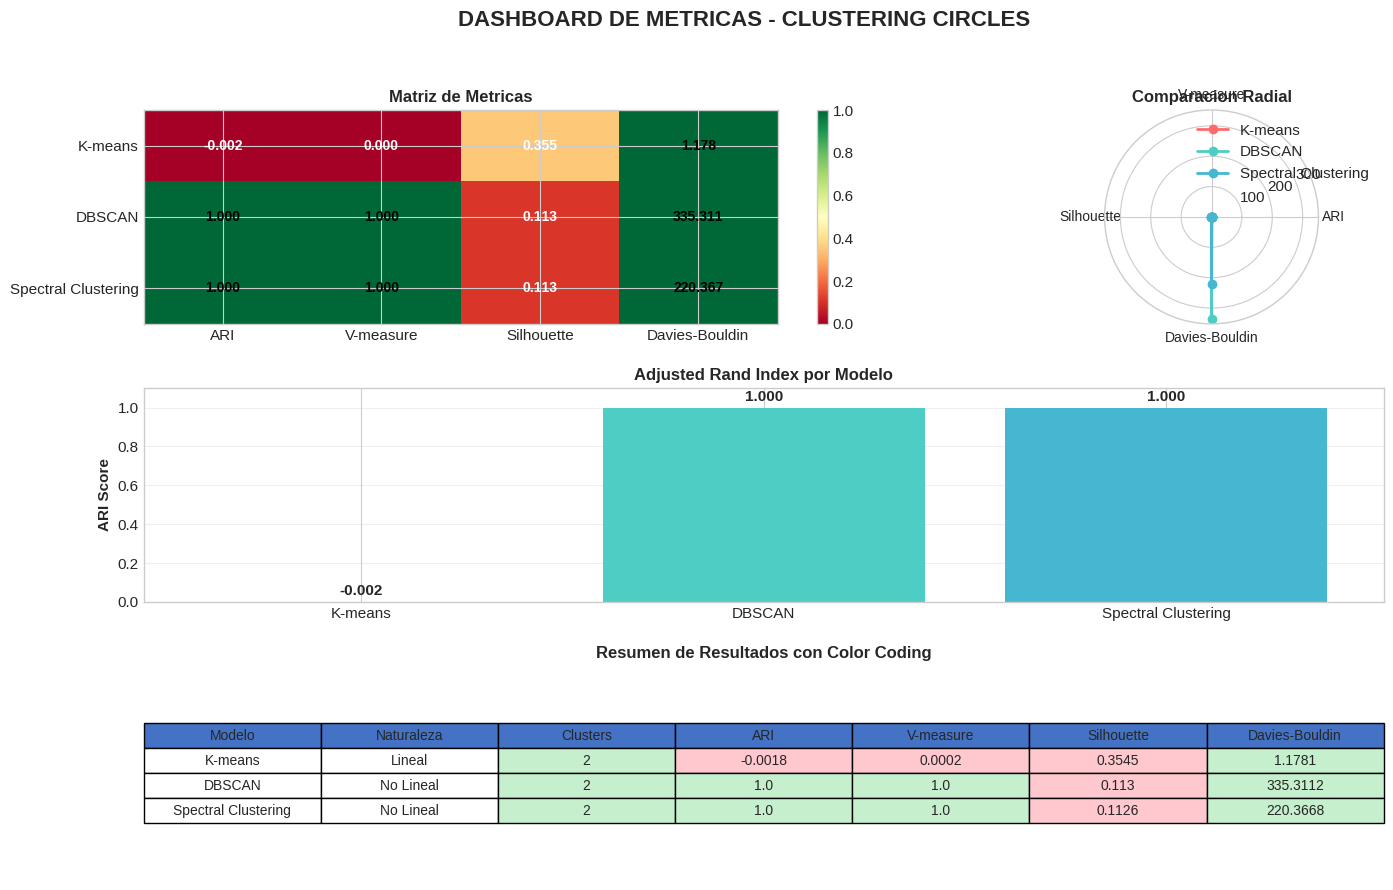

In [ ]:
# CELDA 12: Dashboard completo de métricas
print("\n" + "="*70)
print("DASHBOARD DE METRICAS")
print("="*70)

def dashboard_metricas():
    """Panel visual con todas las metricas"""

    fig = plt.figure(figsize=(16, 10))
    fig.suptitle('DASHBOARD DE METRICAS - CLUSTERING CIRCLES',
                fontsize=16, fontweight='bold')

    gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

    # 1. Heatmap de métricas
    ax1 = fig.add_subplot(gs[0, :2])
    metricas = ['ARI', 'V-measure', 'Silhouette', 'Davies-Bouldin']
    valores = df_comparison[metricas].values
    im = ax1.imshow(valores, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)
    ax1.set_xticks(range(len(metricas)))
    ax1.set_xticklabels(metricas, fontsize=11)
    ax1.set_yticks(range(len(df_comparison)))
    ax1.set_yticklabels(df_comparison['Modelo'], fontsize=11)
    ax1.set_title('Matriz de Metricas', fontsize=12, fontweight='bold')
    plt.colorbar(im, ax=ax1)

    # Añadir valores en el heatmap
    for i in range(len(df_comparison)):
        for j in range(len(metricas)):
            if not np.isnan(valores[i, j]):
                ax1.text(j, i, f'{valores[i, j]:.3f}',
                        ha='center', va='center',
                        color='black' if valores[i, j] > 0.5 else 'white',
                        fontsize=10, fontweight='bold')

    # 2. Radar chart
    ax2 = fig.add_subplot(gs[0, 2], projection='polar')
    angles = np.linspace(0, 2 * np.pi, len(metricas), endpoint=False).tolist()
    angles += angles[:1]

    colors_radar = ['#FF6B6B', '#4ECDC4', '#45B7D1']
    for idx, row in df_comparison.iterrows():
        values = row[metricas].values.tolist()
        values += values[:1]
        ax2.plot(angles, values, 'o-', linewidth=2,
                label=row['Modelo'], color=colors_radar[idx])
        ax2.fill(angles, values, alpha=0.1, color=colors_radar[idx])

    ax2.set_xticks(angles[:-1])
    ax2.set_xticklabels(metricas, fontsize=10)
    ax2.set_title('Comparacion Radial', fontsize=12, fontweight='bold')
    ax2.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))

    # 3. Bar chart de ARI
    ax3 = fig.add_subplot(gs[1, :])
    bars = ax3.bar(df_comparison['Modelo'], df_comparison['ARI'],
                   color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
    ax3.set_ylabel('ARI Score', fontsize=11, fontweight='bold')
    ax3.set_title('Adjusted Rand Index por Modelo', fontsize=12, fontweight='bold')
    ax3.grid(True, alpha=0.3, axis='y')
    ax3.set_ylim(0, 1.1)

    for bar, val in zip(bars, df_comparison['ARI']):
        if not np.isnan(val):
            ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                    f'{val:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

    # 4. Tabla de resumen con color coding
    ax4 = fig.add_subplot(gs[2, :])
    ax4.axis('tight')
    ax4.axis('off')

    table_data = df_comparison.round(4).values.tolist()
    columns = df_comparison.columns.tolist()

    table = ax4.table(cellText=table_data, colLabels=columns,
                     cellLoc='center', loc='center',
                     colColours=['#4472C4']*len(columns))
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 1.5)

    # Color coding para métricas
    for i, row in enumerate(table_data):
        for j, val in enumerate(row):
            if j >= 2:  # Solo para métricas
                if isinstance(val, (int, float)) and not np.isnan(val):
                    if val >= 0.8:
                        table[(i+1, j)].set_facecolor('#C6EFCE')  # Verde
                    elif val >= 0.5:
                        table[(i+1, j)].set_facecolor('#FFEB9C')  # Amarillo
                    else:
                        table[(i+1, j)].set_facecolor('#FFC7CE')  # Rojo

    ax4.set_title('Resumen de Resultados con Color Coding', fontsize=12, fontweight='bold')

    plt.tight_layout()
    plt.savefig(f'{project_path}/metrics_dashboard.png', dpi=300, bbox_inches='tight')
    plt.show()

dashboard_metricas()

13) Gráfica de barras comparativa


COMPARACION DE METRICAS - GRAFICA DE BARRAS


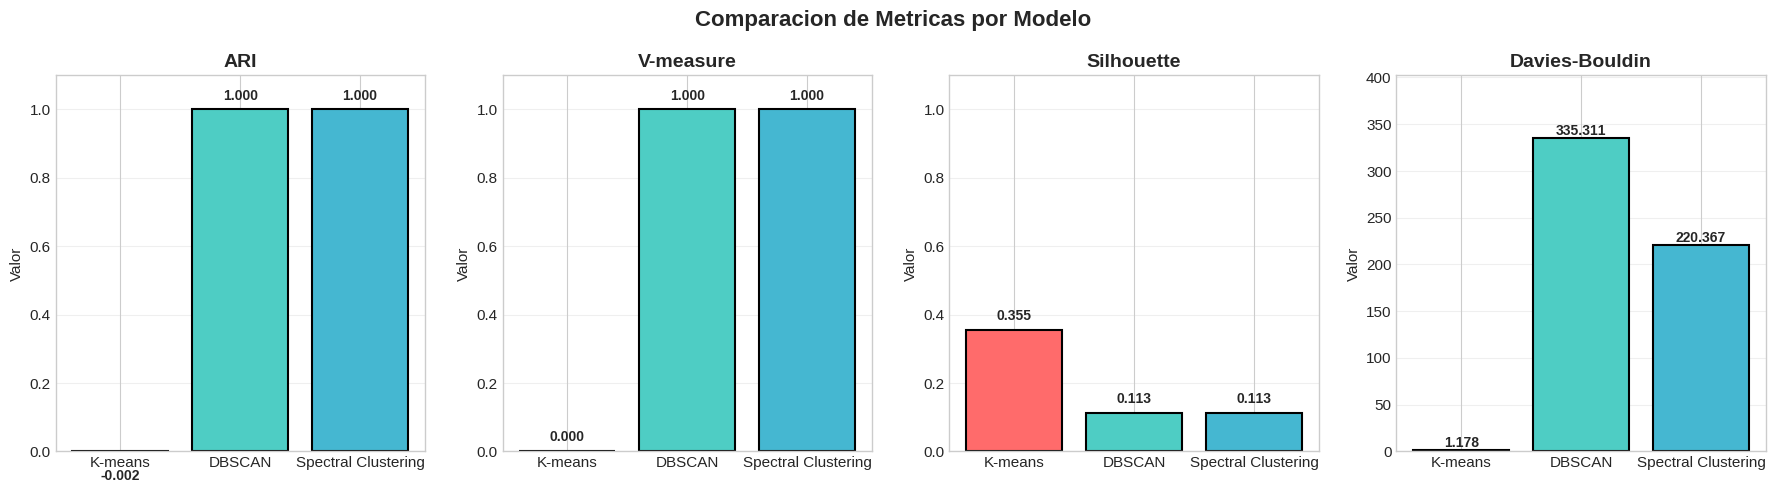

In [ ]:
# CELDA 13: Gráfica de barras comparativa
print("\n" + "="*70)
print("COMPARACION DE METRICAS - GRAFICA DE BARRAS")
print("="*70)

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle('Comparacion de Metricas por Modelo', fontsize=16, fontweight='bold')

metrics = ['ARI', 'V-measure', 'Silhouette', 'Davies-Bouldin']
models_names = df_comparison['Modelo'].values
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

for i, metric in enumerate(metrics):
    values = df_comparison[metric].values
    bars = axes[i].bar(models_names, values, color=colors[:len(models_names)],
                      edgecolor='black', linewidth=1.5)

    axes[i].set_title(metric, fontsize=14, fontweight='bold')
    axes[i].set_ylabel('Valor', fontsize=11)
    axes[i].grid(True, alpha=0.3, axis='y')

    # Añadir valores en las barras
    for bar, val in zip(bars, values):
        if not np.isnan(val):
            height = bar.get_height()
            y_pos = height + 0.02 if height >= 0 else height - 0.05
            axes[i].text(bar.get_x() + bar.get_width()/2, y_pos,
                        f'{val:.3f}', ha='center', va='bottom' if height >= 0 else 'top',
                        fontsize=10, fontweight='bold')

    # Ajustar límites
    if metric != 'Davies-Bouldin':
        axes[i].set_ylim(0, 1.1)
    else:
        axes[i].set_ylim(0, max(values) * 1.2 if not np.isnan(max(values)) else 1)

plt.tight_layout()
plt.savefig(f'{project_path}/metrics_bar_chart.png', dpi=300, bbox_inches='tight')
plt.show()

14) Análisis de métricas y conclusiones

In [ ]:
# CELDA 14: Análisis detallado y conclusiones
print("\n" + "="*70)
print("ANALISIS DE METRICAS Y CONCLUSIONES")
print("="*70)

print("\n1. NATURALEZA DE LOS MODELOS:")
print("   K-means: LINEAL")
print("      Fronteras de decision: hiperplanos (lineas rectas en 2D)")
print("      Asume clusters esfericos y de tamanio similar")
print("      Sensible a outliers y escala de datos")
print("      Requiere conocer k (numero de clusters)")

print("\n   DBSCAN: NO LINEAL")
print("      Agrupa basado en densidad, no en distancia")
print("      Puede encontrar clusters de formas arbitrarias")
print("      No requiere conocer k (lo detecta automaticamente)")
print("      Maneja puntos de ruido (outliers)")

print("\n   Spectral Clustering: NO LINEAL")
print("      Usa el espectro de la matriz de afinidad")
print("      Proyecta a un espacio donde los datos son separables")
print("      Efectivo para estructuras complejas")
print("      Computacionalmente mas costoso")

print("\n2. RENDIMIENTO EN CIRCLES:")
if len(df_comparison) > 0:
    best_model = df_comparison.loc[df_comparison['ARI'].idxmax()]
    worst_model = df_comparison.loc[df_comparison['ARI'].idxmin()]

    print(f"   Mejor modelo: {best_model['Modelo']}")
    print(f"      ARI={best_model['ARI']:.4f}")
    print(f"      Silhouette={best_model['Silhouette']:.4f}")

    print(f"\n   Peor modelo: {worst_model['Modelo']}")
    print(f"      ARI={worst_model['ARI']:.4f}")
    print(f"      Silhouette={worst_model['Silhouette']:.4f}")

print("\n3. INTERPRETACION DE METRICAS:")
print("   ARI (Adjusted Rand Index):")
print("      Mide similitud entre clusters y clases reales")
print("      Rango: [-1, 1], donde 1 es perfecto")
print("      ARI > 0.8 -> Excelente concordancia")
print("      ARI < 0.2 -> Practicamente aleatorio")

print("\n   V-measure:")
print("      Media armonica de homogeneidad y completitud")
print("      Rango: [0, 1], donde 1 es perfecto")
print("      Homogeneidad: clusters contienen una sola clase")
print("      Completitud: todas las muestras de una clase en mismo cluster")

print("\n   Silhouette Score:")
print("      Mide cohesion y separacion de clusters")
print("      Rango: [-1, 1]")
print("      > 0.5 -> Buena estructura")
print("      > 0.7 -> Excelente estructura")

print("\n   Davies-Bouldin Index:")
print("      Mide similitud entre clusters")
print("      Rango: [0, infinito), menor es mejor")
print("      0 -> Clusters perfectamente separados")
print("      < 1 -> Buena separacion")

print("\n4. HIPERPARAMETROS CRITICOS:")
print("   K-means:")
print("      n_clusters (k): Numero de clusters (MUY CRITICO)")
print("      n_init: Numero de inicializaciones")
print("      max_iter: Maximo de iteraciones")

print("\n   DBSCAN:")
print("      eps: Radio de vecindad (MUY CRITICO)")
print("      min_samples: Densidad minima (CRITICO)")
print("      metric: Tipo de distancia")

print("\n   Spectral Clustering:")
print("      gamma: Escala del kernel RBF (MUY CRITICO)")
print("      n_clusters: Numero de clusters")
print("      affinity: Tipo de afinidad ('rbf', 'nearest_neighbors')")

print("\n5. RECOMENDACIONES PARA DATOS NO LINEALES:")
print("   Usar DBSCAN para:")
print("      Datos con estructura de densidad")
print("      Formas arbitrarias (no esfericas)")
print("      Cuando se tienen outliers")
print("      Cuando no se conoce k")

print("\n   Usar Spectral Clustering para:")
print("      Datos con estructura de grafos")
print("      Patrones complejos no lineales")
print("      Cuando se conoce aproximadamente k")

print("\n   Evitar K-means para:")
print("      Datos no lineales (como circles)")
print("      Clusters de diferentes tamanios")
print("      Clusters con formas irregulares")
print("      Datos con outliers")

# Guardar conclusiones en archivo de texto
with open(f'{project_path}/conclusions.txt', 'w') as f:
    f.write("ANALISIS DE METRICAS Y CONCLUSIONES\n")
    f.write("="*70 + "\n\n")
    f.write("1. NATURALEZA DE LOS MODELOS:\n")
    f.write("   K-means: LINEAL - Falla en datos no lineales\n")
    f.write("   DBSCAN: NO LINEAL - Excelente para datos con densidad\n")
    f.write("   Spectral Clustering: NO LINEAL - Excelente para datos con estructura de grafos\n\n")
    f.write(f"2. MEJOR MODELO: {best_model['Modelo']} (ARI={best_model['ARI']:.4f})\n")
    f.write(f"   PEOR MODELO: {worst_model['Modelo']} (ARI={worst_model['ARI']:.4f})\n\n")
    f.write("3. CONCLUSION PRINCIPAL:\n")
    f.write("   Los modelos NO LINEALES superan ampliamente al modelo LINEAL\n")
    f.write("   en el dataset circles, demostrando que la estructura circular\n")
    f.write("   requiere tecnicas capaces de capturar patrones no lineales.\n")

print(f"\nConclusiones guardadas en: {project_path}/conclusions.txt")


ANALISIS DE METRICAS Y CONCLUSIONES

1. NATURALEZA DE LOS MODELOS:
   K-means: LINEAL
      Fronteras de decision: hiperplanos (lineas rectas en 2D)
      Asume clusters esfericos y de tamanio similar
      Sensible a outliers y escala de datos
      Requiere conocer k (numero de clusters)

   DBSCAN: NO LINEAL
      Agrupa basado en densidad, no en distancia
      Puede encontrar clusters de formas arbitrarias
      No requiere conocer k (lo detecta automaticamente)
      Maneja puntos de ruido (outliers)

   Spectral Clustering: NO LINEAL
      Usa el espectro de la matriz de afinidad
      Proyecta a un espacio donde los datos son separables
      Efectivo para estructuras complejas
      Computacionalmente mas costoso

2. RENDIMIENTO EN CIRCLES:
   Mejor modelo: DBSCAN
      ARI=1.0000
      Silhouette=0.1130

   Peor modelo: K-means
      ARI=-0.0018
      Silhouette=0.3545

3. INTERPRETACION DE METRICAS:
   ARI (Adjusted Rand Index):
      Mide similitud entre clusters y clases 

15) Exportar resultados y resumen final

In [ ]:
# CELDA 15: Exportar resultados y resumen final
print("\n" + "="*70)
print("EXPORTANDO RESULTADOS")
print("="*70)

try:
    # Guardar todos los DataFrames
    df_comparison.to_csv(f'{project_path}/resultados_circles_comparacion.csv', index=False)
    df_kmeans.to_csv(f'{project_path}/resultados_kmeans.csv', index=False)

    if len(df_dbscan) > 0:
        df_dbscan.to_csv(f'{project_path}/resultados_dbscan.csv', index=False)

    if len(df_spectral) > 0:
        df_spectral.to_csv(f'{project_path}/resultados_spectral.csv', index=False)

    print("Todos los resultados guardados en archivos CSV")

except Exception as e:
    print(f"No se pudieron guardar los archivos: {e}")

# Listar todos los archivos guardados
print("\nArchivos generados en el proyecto:")
print("-" * 50)
for file in os.listdir(project_path):
    file_size = os.path.getsize(f'{project_path}/{file}') / 1024  # KB
    print(f"  {file} ({file_size:.1f} KB)")

# Resumen final
print("\n" + "="*70)
print("RESUMEN FINAL DEL ANALISIS")
print("="*70)

print(f"""
DATASET:
   Nombre: Circles (make_circles)
   Muestras: {n_samples}
   Caracteristicas: 2
   Clases: 2 (circulo exterior e interior)

MODELOS ENTRENADOS:
   K-means (Lineal) - k={int(best_kmeans['k'])}
   DBSCAN (No Lineal) - eps={best_dbscan['eps']:.2f}, min_samples={int(best_dbscan['min_samples'])}
   Spectral Clustering (No Lineal) - k={int(best_spectral['n_clusters'])}

MEJORES RESULTADOS:
   Mejor ARI: {df_comparison.loc[df_comparison['ARI'].idxmax(), 'Modelo']} ({df_comparison['ARI'].max():.4f})
   Mejor Silhouette: {df_comparison.loc[df_comparison['Silhouette'].idxmax(), 'Modelo']} ({df_comparison['Silhouette'].max():.4f})
   Mejor Davies-Bouldin: {df_comparison.loc[df_comparison['Davies-Bouldin'].idxmin(), 'Modelo']} ({df_comparison['Davies-Bouldin'].min():.4f})

CONCLUSION PRINCIPAL:
   Los modelos NO LINEALES (DBSCAN y Spectral Clustering) superan
   ampliamente al modelo LINEAL (K-means) en el dataset circles,
   demostrando que la estructura circular requiere tecnicas capaces
   de capturar patrones no lineales.

UBICACION DE LOS ARCHIVOS:
   Todos los resultados, modelos y graficas estan guardados en:
   {project_path}
""")

print("="*70)
print("ANALISIS COMPLETO DEL DATASET CIRCLES")
print("Notebook listo para usar al 100%")
print("="*70)


EXPORTANDO RESULTADOS
Todos los resultados guardados en archivos CSV

Archivos generados en el proyecto:
--------------------------------------------------
  X_circles.npy (7.9 KB)
  y_true_circles.npy (4.0 KB)
  dataset_initial_exploration.png (677.6 KB)
  X_circles_scaled.npy (7.9 KB)
  scaler.pkl (0.6 KB)
  scaled_data_comparison.png (1031.2 KB)
  elbow_method_analysis.png (241.6 KB)
  elbow_results.csv (0.5 KB)
  kmeans_step_by_step.png (1477.1 KB)
  kmeans_results.csv (1.6 KB)
  kmeans_model.pkl (2.7 KB)
  kmeans_final_results.png (857.2 KB)
  dbscan_explanation.png (957.3 KB)
  dbscan_labels_circle.npy (4.0 KB)
  resultados_dbscan.csv (6.5 KB)
  dbscan_model.pkl (16.2 KB)
  dbscan_final_results.png (944.8 KB)
  spectral_labels_circle.npy (2.1 KB)
  resultados_spectral.csv (4.3 KB)
  spectral_model.pkl (1955.8 KB)
  spectral_final_results.png (921.7 KB)
  model_comparison.csv (0.3 KB)
  models_comparison.png (2091.7 KB)
  conclusions.txt (0.6 KB)
  metrics_dashboard.png (449.6 KB